# Challenge 01 - Trick-Series Diagnosis

Eight series. Each one is engineered so that a *plausible* transform is the wrong one. For each:
diagnose the structure, choose the stationarity-inducing transform (or argue that none is
appropriate), and — the part that is actually graded — say **which modeling assumption would have
broken** if you had used the obvious alternative.

**Honest baseline** (Chapter 0 [L02](../../chapter_00_problem_formulation/lessons/L02_baselines.md)):
for every series, a persistence forecast and a seasonal-naive forecast at $h=1$ and $h=12$. You may
not claim a series "needs differencing" without showing that it beats these.

**Evaluation protocol** (Chapter 1 [L03](../lessons/L03_temporal_evaluation.md)): rolling-origin,
5 folds, expanding window. No random splits, no fitting anything on the full series.

**Deliverable:** the diagnosis table in Part 4, plus the post-mortem in Part 5.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

RNG = np.random.default_rng(2024)
plt.rcParams.update({"figure.figsize": (11, 2.2), "axes.grid": True, "grid.alpha": 0.3})
N = 480

## Part 1 - The series

Deliberately unlabelled. Do not read the generator until you have written your diagnoses.

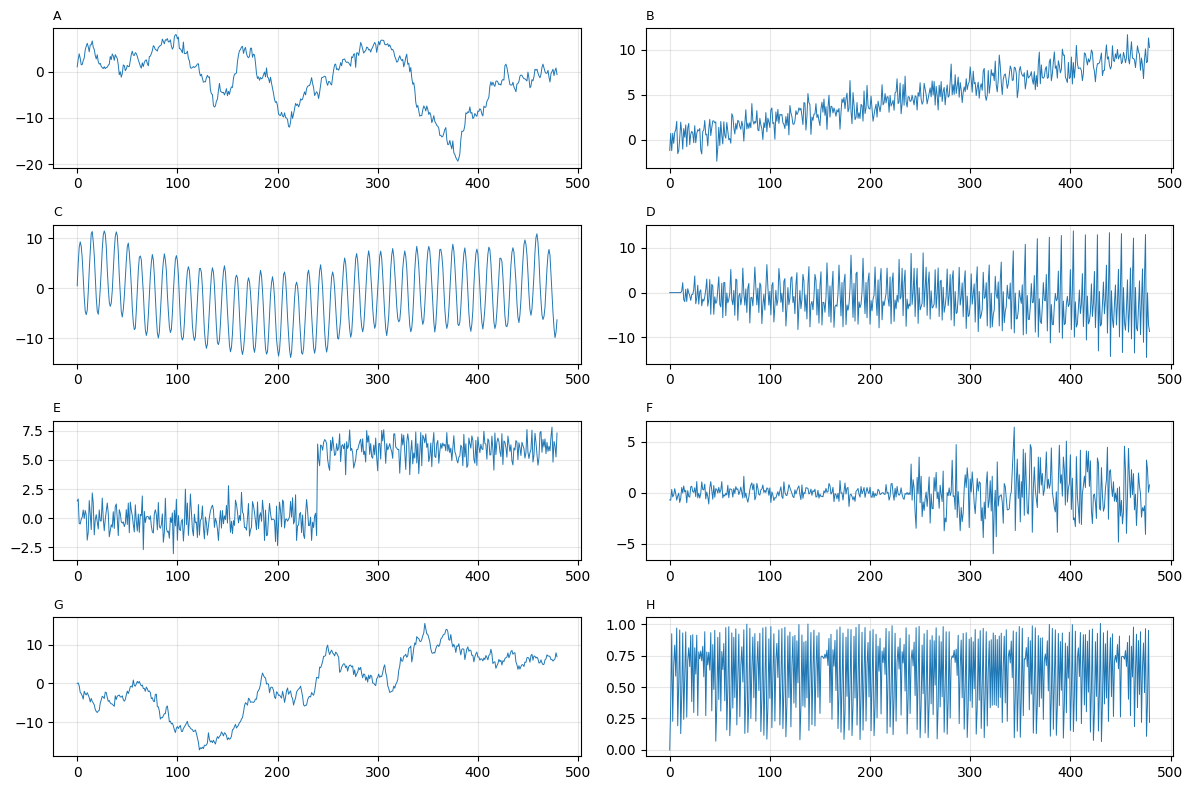

In [2]:
def make_series():
    t = np.arange(N)
    s = {}
    s["A"] = np.cumsum(RNG.normal(0, 1, N))                                   # unit root
    s["B"] = 0.02 * t + RNG.normal(0, 1, N)                                   # deterministic trend
    seas = 8 * np.sin(2 * np.pi * t / 12)
    s["C"] = seas + np.cumsum(RNG.normal(0, 0.4, N))                          # seasonal + unit root
    walk = np.zeros(N)                                                        # seasonal unit root
    for i in range(12, N):
        walk[i] = walk[i - 12] + RNG.normal(0, 1)
    s["D"] = walk
    s["E"] = np.r_[RNG.normal(0, 1, N // 2), RNG.normal(6, 1, N // 2)]        # level break
    s["F"] = RNG.normal(0, 1, N) * (0.5 + 2 * (t > N // 2))                   # variance break
    ar = np.zeros(N)                                                          # near unit root
    for i in range(1, N):
        ar[i] = 0.985 * ar[i - 1] + RNG.normal(0, 1)
    s["G"] = ar
    x = np.zeros(N)                                                           # nonlinear, no ACF
    for i in range(1, N):
        x[i] = 3.9 * x[i - 1] * (1 - x[i - 1]) if 0 < x[i - 1] < 1 else 0.4
    s["H"] = x + RNG.normal(0, 0.02, N)
    return s


series = make_series()
fig, ax = plt.subplots(4, 2, figsize=(12, 8))
for a, (k, v) in zip(ax.ravel(), series.items()):
    a.plot(v, lw=0.7)
    a.set_title(k, loc="left", fontsize=9)
plt.tight_layout()

## Part 2 - Your diagnostic toolkit

Provided so you spend your time diagnosing, not implementing. Add anything you need.

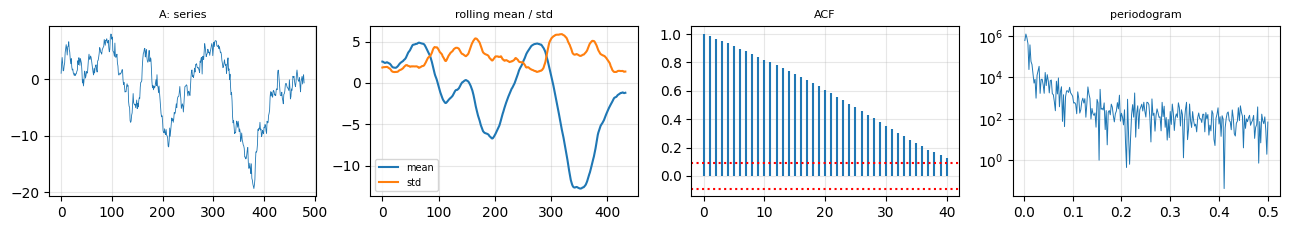

In [3]:
def acf(x, nlags=40):
    x = x - x.mean()
    r = np.correlate(x, x, "full")[len(x) - 1:]
    return r[:nlags + 1] / r[0]


def rolling_stats(x, w=48):
    m = np.convolve(x, np.ones(w) / w, "valid")
    s = np.array([x[i:i + w].std() for i in range(len(x) - w + 1)])
    return m, s


def plot_diag(name, x):
    fig, ax = plt.subplots(1, 4, figsize=(13, 2.4))
    ax[0].plot(x, lw=0.6); ax[0].set_title(f"{name}: series", fontsize=8)
    m, s = rolling_stats(x)
    ax[1].plot(m, label="mean"); ax[1].plot(s, label="std")
    ax[1].legend(fontsize=7); ax[1].set_title("rolling mean / std", fontsize=8)
    ax[2].stem(acf(x), markerfmt=" ", basefmt=" ")
    ax[2].axhline(1.96 / np.sqrt(len(x)), ls=":", c="r"); ax[2].axhline(-1.96 / np.sqrt(len(x)), ls=":", c="r")
    ax[2].set_title("ACF", fontsize=8)
    f = np.fft.rfftfreq(len(x)); P = np.abs(np.fft.rfft(x - x.mean())) ** 2
    ax[3].semilogy(f[1:], P[1:], lw=0.7); ax[3].set_title("periodogram", fontsize=8)
    plt.tight_layout()


plot_diag("A", series["A"])

## Part 3 - Your work

For each series, run `plot_diag`, then try the candidate transforms and re-diagnose. Suggested
candidates: first difference $\nabla$, seasonal difference $\nabla_{12}$, both, log, detrend by OLS
on $t$, split at a break and model per segment, or "leave it alone and model the state explicitly"
(Chapter 2).

```python
# your work here, e.g.
x = series["C"]
plot_diag("C raw", x)
plot_diag("C, first difference", np.diff(x))
plot_diag("C, seasonal difference", x[12:] - x[:-12])
```

Warnings, each of which one of these series is built to trigger:

* A slowly decaying ACF is *not* proof of a unit root — a level break produces the same picture.
* Differencing a trend-stationary series over-differences it: look for a strong negative lag-1
  autocorrelation in the result.
* A flat ACF does not mean unpredictable. Check the ACF of $x_t^2$ and of $|x_t|$, and plot
  $x_t$ against $x_{t-1}$.
* Non-constant variance is not fixed by any amount of differencing.

## Part 4 - Diagnosis table (the deliverable)

Fill this in. One row per series, and the last two columns are the ones that count.

| Series | Diagnosis | Chosen transform | The obvious wrong choice | Which assumption it would have broken |
| --- | --- | --- | --- | --- |
| A | | | | |
| B | | | | |
| C | | | | |
| D | | | | |
| E | | | | |
| F | | | | |
| G | | | | |
| H | | | | |

## Part 5 - Baselines and the post-mortem (required)

1. For each series, run rolling-origin evaluation of: persistence, seasonal naive, and an AR model
   fitted on your transformed series. Report RMSE at $h=1$ and $h=12$ as a **skill score** against
   persistence.
2. Where your transform did **not** beat the naive baselines, say so plainly and explain why.
3. Answer these:
   * Which series did you diagnose wrongly at first, and what was the misleading diagnostic?
   * For series G (a near-unit root), what would ADF and KPSS report, and why is neither answer
     decisive at $T=480$? What would you need to distinguish it?
   * For series H, what does a linear model's residual ACF look like, and why is it not evidence
     that the model is adequate? Tie this to Wold's theorem (Chapter 1
     [L02](../lessons/L02_acf_and_spectrum.md)).
   * Name one place in a *trajectory* pipeline where each of these pathologies would appear.

In [4]:
# starter: rolling-origin skill score, so you have no excuse to skip the baseline
def rolling_origin_rmse(x, predict, h=1, folds=5):
    """predict(history, h) -> forecast h steps ahead."""
    errs = []
    for i in range(folds):
        cut = int(len(x) * (0.5 + 0.1 * i))
        errs.append((predict(x[:cut], h) - x[cut + h - 1]) ** 2)
    return np.sqrt(np.mean(errs))


persistence = lambda hist, h: hist[-1]
seasonal_naive = lambda hist, h: hist[-12 + (h - 1) % 12]

print(f"{'series':>7}{'persist h=1':>13}{'snaive h=1':>12}{'persist h=12':>14}{'snaive h=12':>13}")
for k, v in series.items():
    print(f"{k:>7}{rolling_origin_rmse(v, persistence, 1):>13.3f}"
          f"{rolling_origin_rmse(v, seasonal_naive, 1):>12.3f}"
          f"{rolling_origin_rmse(v, persistence, 12):>14.3f}"
          f"{rolling_origin_rmse(v, seasonal_naive, 12):>13.3f}")

 series  persist h=1  snaive h=1  persist h=12  snaive h=12
      A        1.035       2.359         3.188        3.188
      B        1.365       1.724         1.466        1.466
      C        4.111       1.049         1.201        1.201
      D        3.213       0.975         0.891        0.891
      E        3.578       2.845         2.835        2.835
      F        1.778       2.560         1.625        1.625
      G        1.393       3.877         5.018        5.018
      H        0.465       0.400         0.439        0.439
